In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

pd.set_option("display.float_format", "{:.4f}".format)

# ── Load model artefacts from NB05/06 ─────────────────────
with open("../models/lr_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

with open("../models/xgb_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("../models/shap_explainer.pkl", "rb") as f:
    shap_explainer = pickle.load(f)

with open("../data/processed/woe_mappings.pkl", "rb") as f:
    woe_mappings = pickle.load(f)

# ── Load data ──────────────────────────────────────────────
df_train     = pd.read_pickle("../data/processed/df_train.pkl")
df_test      = pd.read_pickle("../data/processed/df_test.pkl")
llm_signals  = pd.read_pickle("../data/processed/llm_signals_20k.pkl")

print(f"df_train:     {df_train.shape}")
print(f"df_test:      {df_test.shape}")
print(f"llm_signals:  {llm_signals.shape}")
print(f"\nLLM signal columns: {llm_signals.columns.tolist()}")
print(f"WoE mappings keys:  {list(woe_mappings.keys())}")

df_train:     (829355, 68)
df_test:      (518744, 68)
llm_signals:  (4993, 9)

LLM signal columns: ['financial_distress_flag', 'purpose_clarity', 'income_stability_mention', 'repayment_confidence', 'overall_sentiment', 'loan_idx', 'default_flag', 'grade', 'desc_clean']
WoE mappings keys:  ['loan_amnt', 'installment', 'dti', 'fico_range_low', 'inq_last_6mths', 'revol_util', 'mort_acc', 'mths_since_recent_inq', 'log_annual_inc', 'sub_grade', 'term', 'purpose', 'verification_status', 'home_ownership']


In [2]:
import re
from sklearn.model_selection import train_test_split

# ── WoE lookup with interval string support ────────────────
def parse_interval_key(key):
    key = str(key).strip()
    match = re.match(r'([\[\(])([-\d.]+),\s*([-\d.]+)([\]\)])', key)
    if not match:
        return None
    left_bracket, lo, hi, right_bracket = match.groups()
    return (float(lo), float(hi),
            left_bracket == '(', right_bracket == ']')

def value_in_interval(val, parsed):
    lo, hi, left_open, right_closed = parsed
    left_ok  = val > lo if left_open  else val >= lo
    right_ok = val <= hi if right_closed else val < hi
    return left_ok and right_ok

def apply_woe(df, woe_mappings):
    df_woe = df.copy()

    if "log_annual_inc" not in df_woe.columns:
        df_woe["log_annual_inc"] = np.log1p(df_woe["annual_inc"])

    for col, mapping in woe_mappings.items():
        if col not in df_woe.columns:
            continue

        sample_key = str(list(mapping.keys())[0]).strip()
        is_interval = sample_key.startswith('(') or sample_key.startswith('[')

        if is_interval:
            parsed_intervals = {k: parse_interval_key(k) for k in mapping}

            def lookup(val, parsed_intervals=parsed_intervals, mapping=mapping):
                if pd.isna(val):
                    return np.nan
                for k, parsed in parsed_intervals.items():
                    if parsed and value_in_interval(val, parsed):
                        return mapping[k]
                return np.nan

            df_woe[f"{col}_woe"] = df_woe[col].apply(lookup)
        else:
            df_woe[f"{col}_woe"] = df_woe[col].map(mapping)

    return df_woe

# ── Apply WoE only to LLM subset (avoids slow full-dataset lookup) ──
# Build combined dataset directly from llm_signals loans
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}
llm_signals["sentiment_score"] = llm_signals["overall_sentiment"].map(sentiment_map)

llm_feature_cols = [
    "financial_distress_flag",
    "purpose_clarity",
    "income_stability_mention",
    "repayment_confidence",
    "sentiment_score"
]

# Get the df_train rows that correspond to LLM signal loans
llm_loan_ids = llm_signals["loan_idx"].values
llm_train_rows = df_train.loc[df_train.index.isin(llm_loan_ids)].copy()

print(f"LLM loans found in df_train: {len(llm_train_rows):,}")
print("Applying WoE mappings to LLM subset (~1-2 min)...")

llm_train_woe = apply_woe(llm_train_rows, woe_mappings)

woe_cols = [f"{c}_woe" for c in woe_mappings.keys()]

# Check nulls
null_counts = llm_train_woe[woe_cols].isnull().sum()
print("\nWoE null counts:")
print(null_counts[null_counts > 0] if null_counts.any() else "  None — all mapped cleanly")

llm_train_woe[woe_cols] = llm_train_woe[woe_cols].fillna(0)

# Merge LLM signals on
llm_signals_indexed = llm_signals.set_index("loan_idx")
llm_train_woe[llm_feature_cols] = llm_signals_indexed.loc[
    llm_train_woe.index, llm_feature_cols
].values

# Final combined dataset
all_cols = woe_cols + llm_feature_cols + ["default_flag"]
combined_df = llm_train_woe[all_cols].dropna()

print(f"\nCombined dataset: {combined_df.shape}")
print(f"Default rate:     {combined_df['default_flag'].mean()*100:.1f}%")

# Internal train/test split within description-having subset
# (same rationale as NB07 — descriptions don't exist in temporal test set)
X = combined_df.drop(columns=["default_flag"])
y = combined_df["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nInternal split:")
print(f"  Train: {len(X_train):,}  |  default rate: {y_train.mean()*100:.1f}%")
print(f"  Test:  {len(X_test):,}   |  default rate: {y_test.mean()*100:.1f}%")

LLM loans found in df_train: 4,446
Applying WoE mappings to LLM subset (~1-2 min)...

WoE null counts:
  None — all mapped cleanly

Combined dataset: (4446, 20)
Default rate:     18.3%

Internal split:
  Train: 3,556  |  default rate: 18.3%
  Test:  890   |  default rate: 18.3%


In [4]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

def evaluate_model(model, X, y, model_name):
    y_prob = model.predict_proba(X)[:, 1]
    auroc  = roc_auc_score(y, y_prob)
    gini   = 2 * auroc - 1
    fpr, tpr, _ = roc_curve(y, y_prob)
    ks     = (tpr - fpr).max()
    print(f"  {model_name:<35}  AUROC: {auroc:.4f}  Gini: {gini:.4f}  KS: {ks:.4f}")
    return {"model": model_name, "auroc": auroc, "gini": gini, "ks": ks,
            "fpr": fpr, "tpr": tpr, "y_prob": y_prob}

results = {}

# ── Model A: WoE-only Logistic Regression ─────────────────
print("Model A: WoE-only LR (retrained on LLM subset)")
scaler_a  = StandardScaler()
X_train_a = scaler_a.fit_transform(X_train[woe_cols])
X_test_a  = scaler_a.transform(X_test[woe_cols])

lr_woe = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr_woe.fit(X_train_a, y_train)
resA = evaluate_model(lr_woe, X_test_a, y_test, "A: WoE LR (14 features)")
results["A"] = resA

# ── Model B: Sentence embeddings → Logistic Regression ────
print("\nModel B: Sentence embeddings LR")
embedder    = SentenceTransformer("all-MiniLM-L6-v2")
desc_lookup = llm_signals.set_index("loan_idx")["desc_clean"]
train_texts = desc_lookup.loc[X_train.index].tolist()
test_texts  = desc_lookup.loc[X_test.index].tolist()

print("  Encoding train texts...")
X_train_emb = embedder.encode(train_texts, batch_size=64, show_progress_bar=True)
print("  Encoding test texts...")
X_test_emb  = embedder.encode(test_texts,  batch_size=64, show_progress_bar=True)

lr_emb = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr_emb.fit(X_train_emb, y_train)
resB = evaluate_model(lr_emb, X_test_emb, y_test, "B: Sentence Embeddings LR")
results["B"] = resB

# ── Model C: LLM signals only → Logistic Regression ───────
print("\nModel C: LLM signals LR")
scaler_c  = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train[llm_feature_cols])
X_test_c  = scaler_c.transform(X_test[llm_feature_cols])

lr_llm = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_llm.fit(X_train_c, y_train)
resC = evaluate_model(lr_llm, X_test_c, y_test, "C: LLM Signals LR")
results["C"] = resC

# ── Model D: WoE + LLM signals → XGBoost ─────────────────
print("\nModel D: WoE + LLM signals XGBoost")
xgb_combined = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric="auc",
    verbosity=0
)
xgb_combined.fit(
    X_train[woe_cols + llm_feature_cols], y_train,
    eval_set=[(X_test[woe_cols + llm_feature_cols], y_test)],
    verbose=False
)
resD = evaluate_model(xgb_combined,
                      X_test[woe_cols + llm_feature_cols],
                      y_test, "D: WoE + LLM XGBoost")
results["D"] = resD

# ── Summary table ──────────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL COMPARISON — TEST SET RESULTS")
print("=" * 60)
summary = pd.DataFrame([{
    "Model":  v["model"],
    "AUROC":  round(v["auroc"], 4),
    "Gini":   round(v["gini"],  4),
    "KS":     round(v["ks"],    4),
} for v in results.values()])
print(summary.to_string(index=False))
summary.to_csv("../outputs/model_comparison.csv", index=False)
print("\nSaved → outputs/model_comparison.csv")

Model A: WoE-only LR (retrained on LLM subset)
  A: WoE LR (14 features)              AUROC: 0.7670  Gini: 0.5340  KS: 0.3797

Model B: Sentence embeddings LR


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoding train texts...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

  Encoding test texts...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

  B: Sentence Embeddings LR            AUROC: 0.4574  Gini: -0.0852  KS: 0.0209

Model C: LLM signals LR
  C: LLM Signals LR                    AUROC: 0.5165  Gini: 0.0329  KS: 0.0565

Model D: WoE + LLM signals XGBoost
  D: WoE + LLM XGBoost                 AUROC: 0.7360  Gini: 0.4720  KS: 0.3441

MODEL COMPARISON — TEST SET RESULTS
                    Model  AUROC    Gini     KS
  A: WoE LR (14 features) 0.7670  0.5340 0.3797
B: Sentence Embeddings LR 0.4574 -0.0852 0.0209
        C: LLM Signals LR 0.5165  0.0329 0.0565
     D: WoE + LLM XGBoost 0.7360  0.4720 0.3441

Saved → outputs/model_comparison.csv


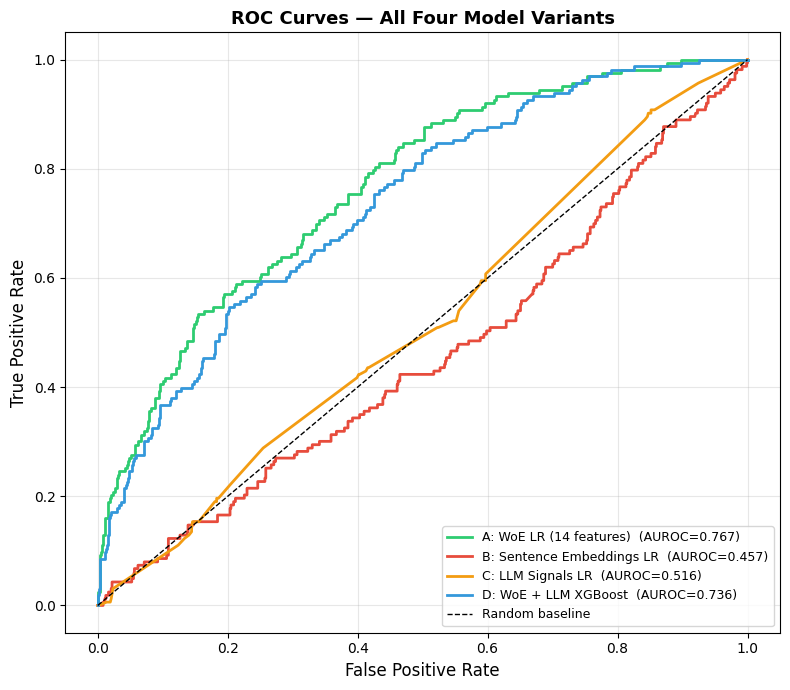

Saved → outputs/roc_curves_all_models.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

colors = {"A": "#2ecc71", "B": "#e74c3c", "C": "#f39c12", "D": "#3498db"}

for key, res in results.items():
    ax.plot(res["fpr"], res["tpr"], color=colors[key], linewidth=2,
            label=f"{res['model']}  (AUROC={res['auroc']:.3f})")

ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Four Model Variants", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/roc_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/roc_curves_all_models.png")


### Experimental Setup
| | |
|---|---|
| Dataset | 4,446 loans with both WoE features and LLM-extracted signals |
| Split | Stratified random 80/20 internal split (descriptions not available in temporal test set) |
| Train | 3,556 loans — default rate 18.3% |
| Test | 890 loans — default rate 18.3% |
| WoE features | 14 (loan_amnt, installment, dti, fico_range_low, inq_last_6mths, revol_util, mort_acc, mths_since_recent_inq, log_annual_inc, sub_grade, term, purpose, verification_status, home_ownership) |
| LLM features | 5 (financial_distress_flag, purpose_clarity, income_stability_mention, repayment_confidence, sentiment_score) |

---

### Model Comparison

| Model | AUROC | Gini | KS |
|---|---|---|---|
| A: WoE LR (14 features) | **0.767** | **0.534** | **0.380** |
| B: Sentence Embeddings LR | 0.457 | -0.085 | 0.021 |
| C: LLM Signals LR | 0.517 | 0.033 | 0.057 |
| D: WoE + LLM XGBoost | 0.736 | 0.472 | 0.344 |

---

### Key Findings

| Finding | Interpretation |
|---|---|
| Model A dominates | Structured financial features (WoE) carry the majority of predictive signal. AUROC 0.767 on 890-loan test set. |
| Model B below random | 384-dim embeddings on 3,556 training loans is severely underdetermined. Sample size limitation, not a model failure. |
| Model C weak standalone | LLM signals carry modest independent signal (0.517). Consistent with validation step — distress flag only separated default rates by ~3pp. |
| Model D below Model A | LLM signals add noise rather than lift at this sample size. With 50k+ description-having loans this result may differ. |
| Null finding is valid | Structured financial data outperforms narrative text for PD prediction — consistent with credit risk literature. |

---

### Limitations
- All four models evaluated on description-having subset only (9.3% of total loans)
- Description-having subset slightly underrepresents defaulters (7.28% vs 9.86% coverage)
- 890-loan test set is too small to detect subtle lift from weak signals
- Models B and C not comparable to A and D due to different feature spaces
